# 7. Streamlit app for classification model

🔹 A. Exploration (historical data) - transparency + insight

Users can:

- Select state
- Select time range  
- View:
    - biodiversity observations
    - anomalies (your target)
    - weather variables

🔹 B. Prediction (model) - real-world application

Users can:

- Input:
    - state
    - month/year (or future scenario)
    - weather conditions (different climate change scenarios)
- Output:
    - probability of biodiversity anomaly
    - classification (shock / no shock)

*Note - run multiple simulations to calculate uncertainty around predictions*
for i in range(100):
    simulate weather
    predict anomalies
    count anomalies

mean +- std across simulations

In [ ]:
import sys
import os
sys.path.append(os.path.abspath("../src")) 

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import joblib
from utils import simulate_future, forecast_bioshocks, forecast_biodiversity

In [2]:
# Load data
full_df = pd.read_parquet('../Data/Processed/full_df.parquet')

# Load model
model_bundle = joblib.load("../models/production_model_classifier.pkl")
model = model_bundle['model']

# Get features
features = model_bundle['features']

# Get optimised proba threshold
threshold = model_bundle['threshold']

In [3]:
df = simulate_future(full_df.loc[full_df['state']=='Berlin'], features, 'business as usual', sim_length=50)
preds = forecast_bioshocks(df, model, features, threshold)

preds.groupby('year')['biodiversity_anomaly'].sum()

year
2025    4
2026    4
2027    4
2028    4
2029    4
2030    4
2031    4
2032    4
2033    4
2034    4
2035    4
2036    4
2037    4
2038    4
2039    5
2040    4
2041    4
2042    4
2043    5
2044    4
2045    4
2046    4
2047    4
2048    4
2049    4
2050    4
2051    4
2052    4
2053    4
2054    4
2055    4
2056    4
2057    4
2058    4
2059    4
2060    4
2061    4
2062    4
2063    4
2064    4
2065    4
2066    4
2067    4
2068    4
2069    4
2070    4
2071    4
2072    4
2073    4
2074    4
Name: biodiversity_anomaly, dtype: int64

Check feature sensitivity

Are simulated climate features actually changing across years?

In [4]:
import matplotlib.pyplot as plt

%matplotlib inline

def plot_variable_by_state(df, year_col, state_col, value_col):
    plt.figure(figsize=(12, 6))

    for state, group in df.groupby(state_col):
        group = group.sort_values(year_col)

        plt.plot(
            group[year_col],
            group[value_col],
            marker='o',
            linewidth=1,
            alpha=0.7,
            label=state
        )

    plt.xlabel("Year")
    plt.ylabel(value_col)
    plt.title(f"{value_col} by State over Time")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

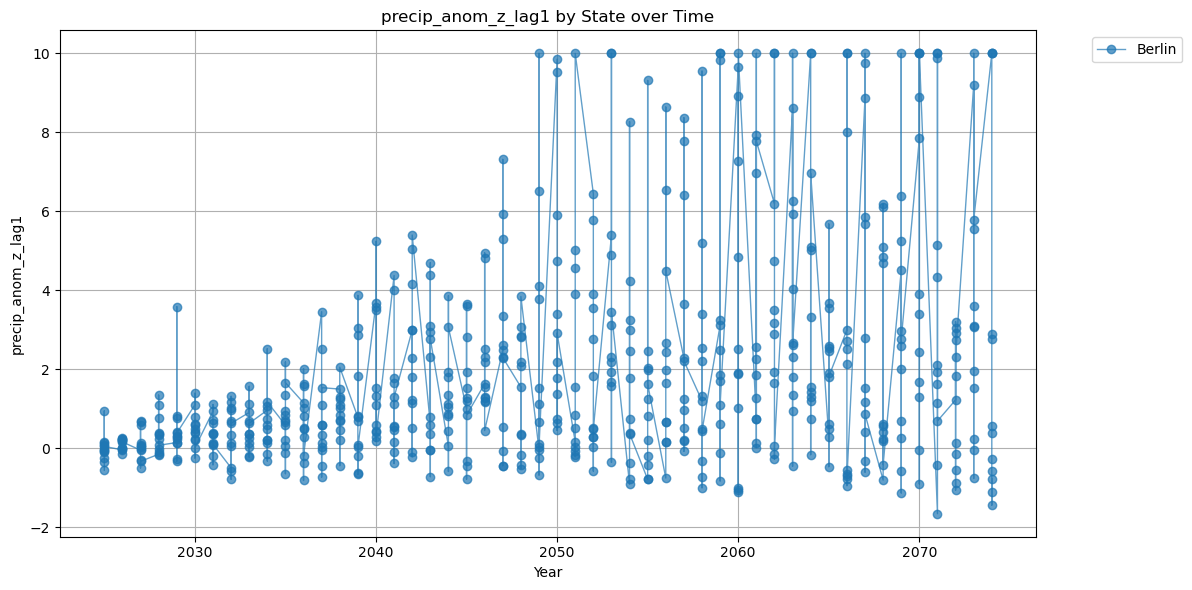

In [6]:
plot_variable_by_state(df.loc[df['state']=='Berlin'], 'year', 'state', 'precip_anom_z_lag1')

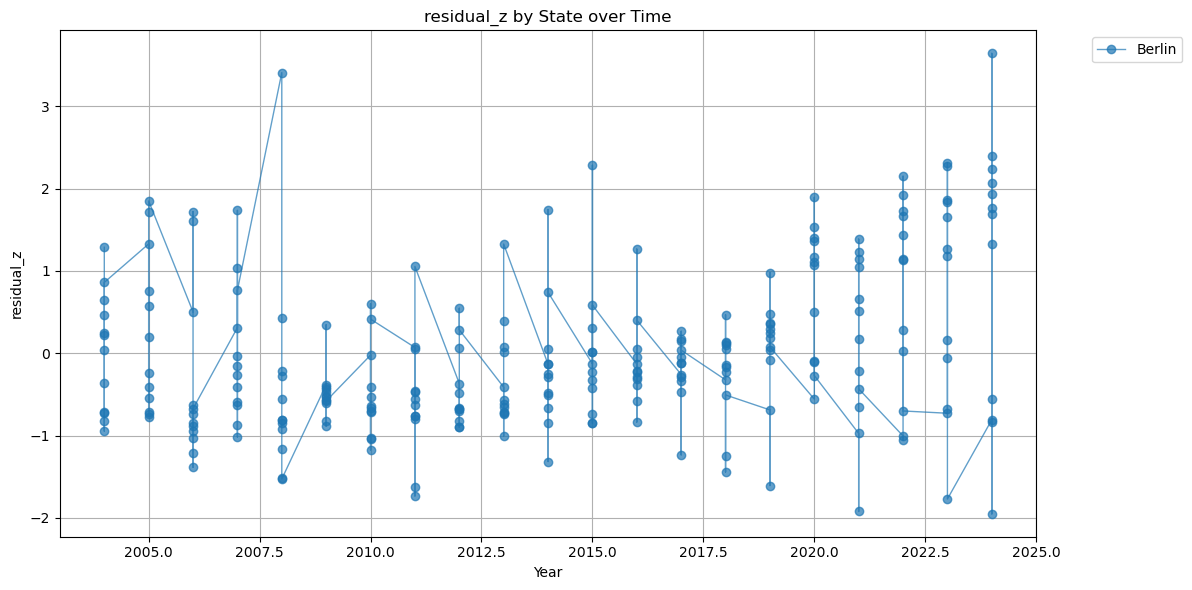

In [15]:
plot_variable_by_state(full_df.loc[full_df['state']=='Berlin'], 'year', 'state', 'residual_z')

In [9]:
full_df[['log_n_obs', 'residual_z']].corr()

,log_n_obs,residual_z
log_n_obs,1.00000,-0.22014
residual_z,-0.22014,1.00000


In [8]:
# -----------------------------
# Load model bundle
# -----------------------------
@st.cache_resource
def load_model_bundle():
    return joblib.load("../models/production_model.pkl")

bundle = load_model_bundle()

model = bundle['model']
features = bundle['features']
threshold = bundle['threshold']

# -----------------------------
# Import functions
# -----------------------------

from utils import simulate_future, forecast_bioshocks

# -----------------------------
# Climate scenarios
# -----------------------------
SCENARIOS = {
    "Best case": {
        "temp increase": 1.5,
        "precipitation change": 0.1
    },
    "Moderate": {
        "temp increase": 3,
        "precipitation change": 0.2
    },
    "Worst case": {
        "temp increase": 5,
        "precipitation change": 0.3
    }
}
# -----------------------------
# UI
# -----------------------------
st.title("🌿 Biodiversity Anomaly Forecast")

st.write("Simulate biodiversity anomalies under climate scenarios.")

# State selection
states = ["Berlin", "Bavaria", "Saxony", "Hesse"]  # replace with your real list
selected_state = st.selectbox("Select Bundesland", states)

# Scenario selection
selected_scenario = st.radio(
    "Select Climate Scenario",
    list(SCENARIOS.keys())
)

scenario = SCENARIOS[selected_scenario]

# -----------------------------
# Predict button
# -----------------------------
if st.button("Predict"):

    st.subheader("Running simulation...")

    # 1. simulate future climate + features
    future_df = simulate_future_weather(
        state=selected_state,
        scenario=scenario
    )

    # 2. predict anomalies
    preds = predict_anomalies(
        future_df,
        bundle=bundle
    )

    # -----------------------------
    # 3. Aggregate per year
    # -----------------------------
    yearly = (
        preds.groupby("future_year_offset")["prediction"]
        .sum()
        .reset_index()
    )

    yearly.rename(
        columns={"prediction": "n_anomalies"},
        inplace=True
    )

    total = yearly["n_anomalies"].sum()

    # -----------------------------
    # 4. Output text
    # -----------------------------
    st.subheader("Results")

    st.write(
        f"**Total predicted anomaly months (10 years): {int(total)}**"
    )

    st.write(
        f"Average per year: {total/10:.1f}"
    )

    # -----------------------------
    # 5. Plot
    # -----------------------------
    fig, ax = plt.subplots()

    ax.plot(
        yearly["future_year_offset"],
        yearly["n_anomalies"],
        marker="o"
    )

    ax.set_xlabel("Year (future offset)")
    ax.set_ylabel("Number of anomaly months")
    ax.set_title(f"{selected_state} — {selected_scenario}")

    ax.grid(True)

    st.pyplot(fig)

    # -----------------------------
    # 6. Optional: raw table
    # -----------------------------
    with st.expander("Show yearly data"):
        st.dataframe(yearly)

2026-04-14 16:59:12.592 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 16:59:12.652 
  command:

    streamlit run C:\Users\Darach\AppData\Roaming\Python\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-14 16:59:12.652 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 16:59:12.653 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 16:59:12.653 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 16:59:12.654 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 16:59:12.655 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 16:59:12.655 Thr